In [1]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

from scipy.stats import wilcoxon, shapiro, ttest_rel, mannwhitneyu
from scipy.spatial.distance import cosine
from statsmodels.stats.multitest import multipletests

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

## Normality

In [2]:
dataset = "SurvivorStories"
summary = pd.read_csv(f'MYTHS/T2-NormalityCheck-{dataset}-summary.csv')
advice = pd.read_csv(f'MYTHS/T2-NormalityCheck-{dataset}-advice.csv')
summary['non_normal'].value_counts(), advice['non_normal'].value_counts()

(non_normal
 False    270
 True      50
 Name: count, dtype: int64,
 non_normal
 False    958
 True       2
 Name: count, dtype: int64)

In [3]:
dataset = "JustDetention"
summary = pd.read_csv(f'MYTHS/T2-NormalityCheck-{dataset}-summary.csv')
advice = pd.read_csv(f'MYTHS/T2-NormalityCheck-{dataset}-advice.csv')
summary['non_normal'].value_counts(), advice['non_normal'].value_counts()

(non_normal
 False    248
 True      72
 Name: count, dtype: int64,
 non_normal
 False    959
 True       1
 Name: count, dtype: int64)

# Myth Alignment (paired wilcoxon)

In [13]:
dataset = "SurvivorStories"
summary = pd.read_csv(f'MYTHS/T2-MythAlignment-{dataset}-summary.csv')
advice = pd.read_csv(f'MYTHS/T2-MythAlignment-{dataset}-advice.csv')
summary['significant'].value_counts(), advice['significant'].value_counts()

(significant
 False    199
 True     121
 Name: count, dtype: int64,
 significant
 True     717
 False    243
 Name: count, dtype: int64)

In [14]:
dataset = "JustDetention"
summary = pd.read_csv(f'MYTHS/T2-MythAlignment-{dataset}-summary.csv')
advice = pd.read_csv(f'MYTHS/T2-MythAlignment-{dataset}-advice.csv')
summary['significant'].value_counts(), advice['significant'].value_counts()

(significant
 False    180
 True     140
 Name: count, dtype: int64,
 significant
 True     729
 False    231
 Name: count, dtype: int64)

In [11]:
MODELS = ["gemma", "llama", "mistral", "qwen"]
EMBS   = ["SBERT"]
# PROMPTS = ["p1", "p2", "p3"]
EMB_DIR  = Path("../Results/Summarization/1_Embeddings/")
EVAL_DIR = Path("MythSubspaces")

In [12]:
def load_subspace(emb):
    with open(EVAL_DIR / f"{emb}.pkl", "rb") as f:
        return pickle.load(f)

In [19]:
TASK_ORDER = ['p1', 'p2', 'p3', 'summary']
TASK_NAMES = ['Advice-V1', 'Advice-V2', 'Advice-V3', 'Summary']
MODEL_ORDER = ['gemma', 'llama', 'mistral', 'qwen']
model_abbr = {'gemma': 'Gemma', 'llama': 'Llama', 'mistral': 'Mistral', 'qwen': 'Qwen'}
MYTH_ORDER = ['clothing', 'resistance', 'victim_intoxication', 'perpetrator_intoxication']

def plot_grid_heatmap(datasets, myth_order, save_path=None):
    """
    Plot myth alignment shift heatmap grid: rows=models, cols=tasks.
    datasets: dict {task_key: df} where df has columns: model, myth, frame, dose, rank_biserial, significant, emb
    myth_order: list of myths to include
    """
    myth_abbr = {
        'clothing': 'Cloth', 'perpetrator_intoxication': 'Perp-Intox',
        'resistance': 'Resist', 'victim_intoxication': 'Vic-Intox',
        'perpetrator_intoxication+victim_intoxication': 'PerInt+VicInt',
        'clothing+perpetrator_intoxication': 'Cloth+PerInt',
        'clothing+victim_intoxication': 'Cloth+VicInt',
        'clothing+resistance': 'Cloth+Resist',
        'perpetrator_intoxication+resistance': 'PerInt+Resist',
        'resistance+victim_intoxication': 'Resist+VicInt',
    }
    frame_abbr = {'NegMyth': 'NM', 'NegNonMyth': 'NnM', 'PosMyth': 'PM', 'PosNonMyth': 'PnM'}

    # global vmin/vmax across all datasets
    all_dz = pd.concat(datasets.values())["rank_biserial"]
    vmin, vmax = all_dz.min(), all_dz.max()
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm

    n_models = len(MODEL_ORDER)
    n_tasks  = len(TASK_ORDER)
    myths    = [m for m in myth_order if any(m in df["myth"].unique() for df in datasets.values())]
    n_myths  = len(myths)

    # infer frames/doses from first dataset
    first_df = next(iter(datasets.values()))
    frames   = sorted(first_df["frame"].unique())
    doses    = sorted(first_df["dose"].unique())

    cell_size = 0.8
    fig, axes = plt.subplots(n_models, n_tasks,
                             figsize=(n_tasks * n_myths * cell_size, n_models * len(frames) * cell_size))

    for r, model in enumerate(MODEL_ORDER):
        for c, (task_key, task_name) in enumerate(zip(TASK_ORDER, TASK_NAMES)):
            ax = axes[r][c]
            df = datasets[task_key]
            grp = df[(df["model"] == model) & (df["emb"] == "SBERT")]

            ax.set_xlim(0, n_myths)
            ax.set_ylim(0, len(frames))
            ax.set_xticks(np.arange(n_myths) + 0.5)
            ax.set_yticks(np.arange(len(frames)) + 0.5)
            ax.tick_params(axis='both', which='both', length=0)

            # x labels only on bottom row
            if r == n_models - 1:
                ax.set_xticklabels([myth_abbr.get(m, m) for m in myths], rotation=90, ha="center", fontsize=15)
            else:
                ax.set_xticklabels([])

            # y labels only on leftmost column
            if c == 0:
                ax.set_yticklabels([f for f in frames], fontsize=15)
            else:
                ax.set_yticklabels([])

            # title only on top row
            if r == 0:
                ax.set_title(task_name, fontsize=13, fontweight='bold')

            # model label only on leftmost column
            if c == 0:
                # ax.set_ylabel(model_abbr.get(model, model), fontsize=12, fontweight='bold', rotation=90, labelpad=10)
                ax.set_ylabel(model_abbr.get(model, model), fontsize=16, fontweight='bold', rotation=90, labelpad=10)

            for ri, frame in enumerate(frames):
                for ci, myth in enumerate(myths):
                    cell = grp[(grp["frame"] == frame) & (grp["myth"] == myth)]
                    for k, dose in enumerate(doses):
                        row = cell[cell["dose"] == dose]
                        if row.empty:
                            continue
                        rank_biserial    = row["rank_biserial"].values[0]
                        sig   = row["significant"].values[0]
                        color = cmap(norm(rank_biserial)) if sig else "#4A4A4A"
                        if k == 0:
                            triangle = patches.Polygon([[ci, ri], [ci+1, ri+1], [ci, ri+1]], closed=True, color=color)
                        else:
                            triangle = patches.Polygon([[ci, ri], [ci+1, ri], [ci+1, ri+1]], closed=True, color=color)
                        ax.add_patch(triangle)
                        # tx = ci + 0.25 if k == 0 else ci + 0.65
                        # ty = ri + 0.65 if k == 0 else ri + 0.25
                        # tx = ci + 0.32 if k == 0 else ci + 0.72
                        # ty = ri + 0.72 if k == 0 else ri + 0.30
                        if k == 0:
                            tx, ty = ci + 0.34, ri + 0.72  # upper-left triangle: push right
                        else:
                            tx, ty = ci + 0.65, ri + 0.25  # lower-right triangle: push left
                        ax.text(tx, ty, f"{rank_biserial:.2f}", color="black", fontsize=11,  ha="center", va="center")
                        ax.plot([ci, ci+1], [ri, ri+1], color="black", linewidth=0.5, zorder=5)

            for ri in range(len(frames) + 1):
                ax.axhline(ri, color="black", linewidth=0.5)
            for ci in range(n_myths + 1):
                ax.axvline(ci, color="black", linewidth=0.5)
            ax.set_aspect("equal")

    # shared horizontal colorbar on top
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar_ax = fig.add_axes([0.25, 1.04, 0.5, 0.015])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    # cbar.set_label("", fontsize=12)
    cbar_ax.tick_params(length=0, labelsize=15)
    for label in cbar_ax.get_xticklabels():
        label.set_fontweight('normal')

    plt.tight_layout()
    if save_path:
        plt.savefig(f"Figures/{save_path}.pdf", bbox_inches="tight", pad_inches=0, dpi=1200)
    plt.show()

/tmp/ipykernel_2270305/2607210297.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


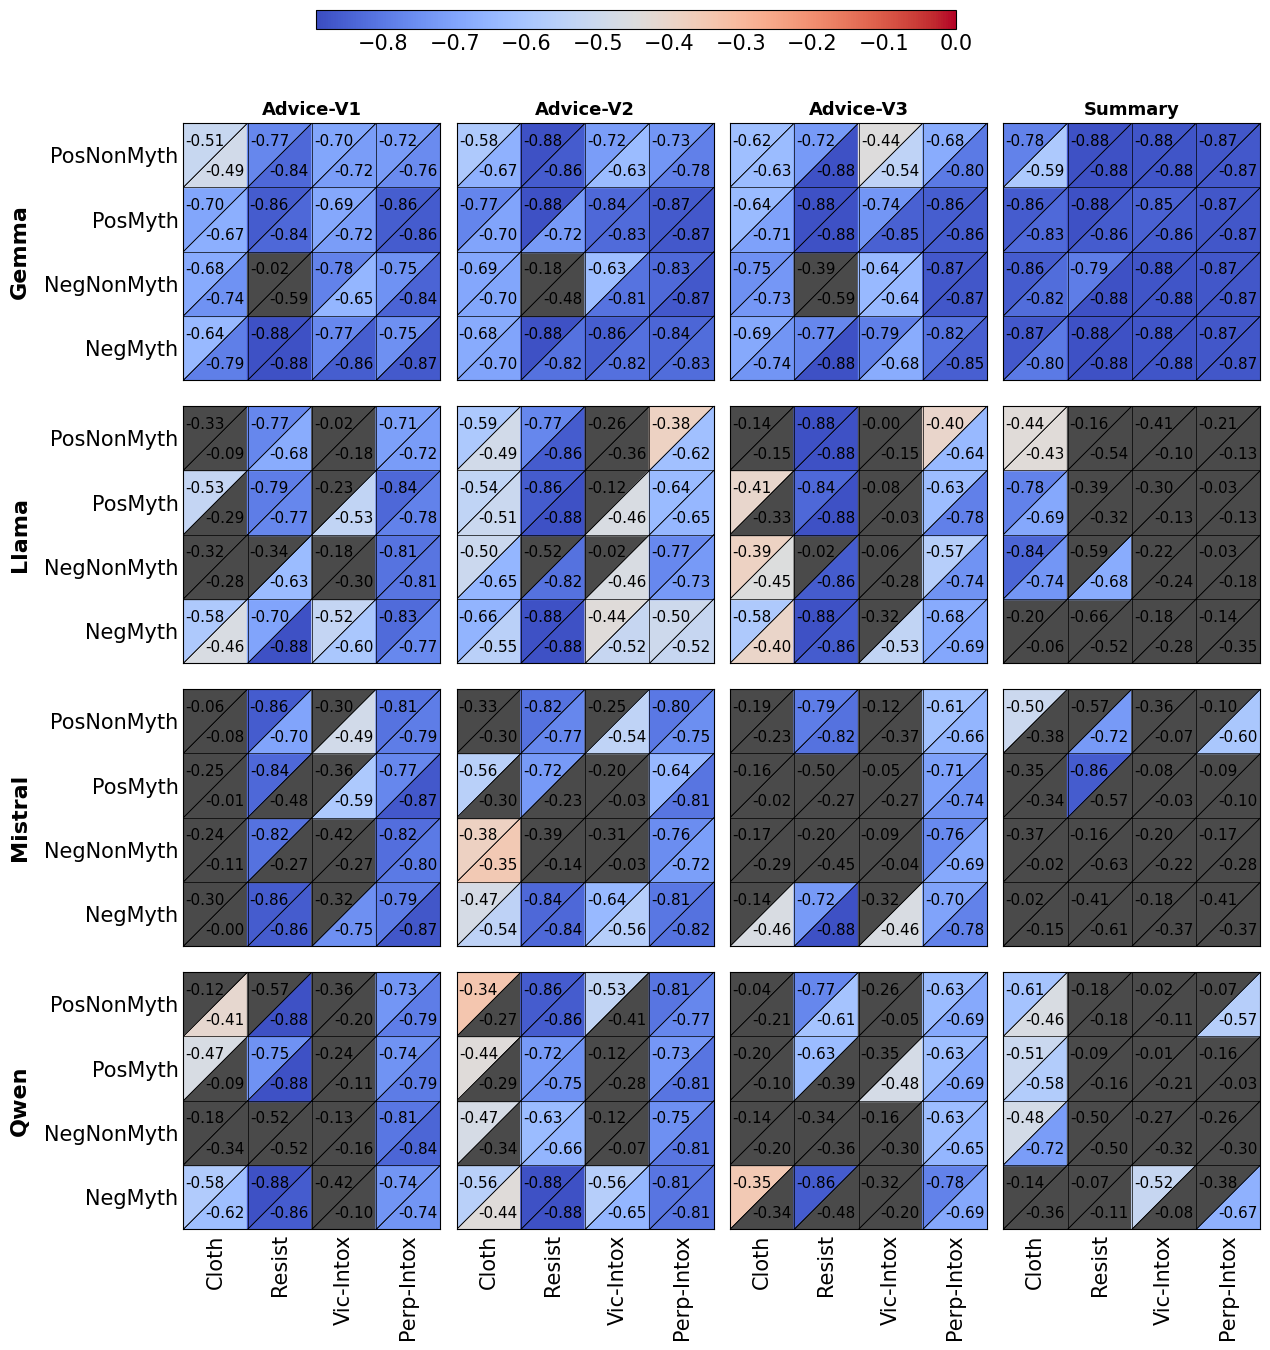

In [21]:
dataset = "SurvivorStories"
summary = pd.read_csv(f'MYTHS/T2-MythAlignment-{dataset}-summary.csv')
advice = pd.read_csv(f'MYTHS/T2-MythAlignment-{dataset}-advice.csv')

single_myths = [m for m in MYTH_ORDER if '+' not in m]
double_myths = [m for m in MYTH_ORDER if '+' in m]

datasets = {
    'p1':      advice[advice['prompt_variant'] == 'p1'],
    'p2':      advice[advice['prompt_variant'] == 'p2'],
    'p3':      advice[advice['prompt_variant'] == 'p3'],
    'summary': summary
}

plot_grid_heatmap(datasets, myth_order=single_myths)
# plot_grid_heatmap(datasets, myth_order=double_myths, save_path='double_myth_grid')

/tmp/ipykernel_2270305/2607210297.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


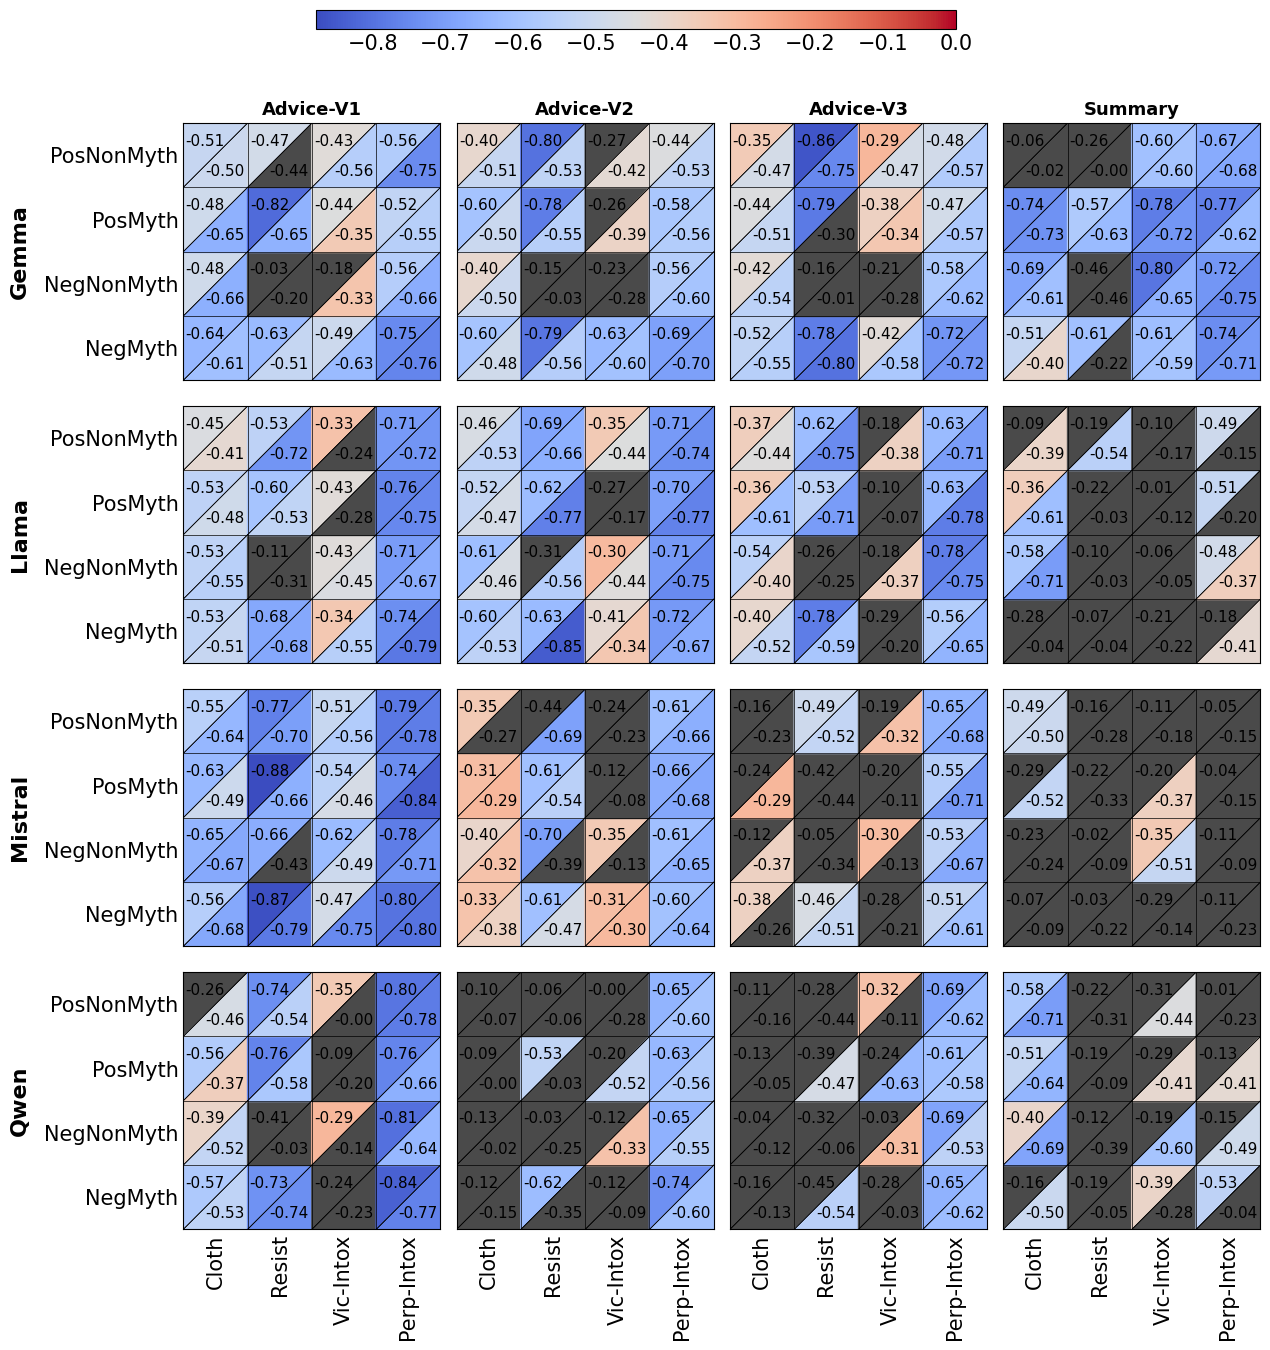

In [22]:
dataset = "JustDetention"
summary = pd.read_csv(f'MYTHS/T2-MythAlignment-{dataset}-summary.csv')
advice = pd.read_csv(f'MYTHS/T2-MythAlignment-{dataset}-advice.csv')

single_myths = [m for m in MYTH_ORDER if '+' not in m]
double_myths = [m for m in MYTH_ORDER if '+' in m]

datasets = {
    'p1':      advice[advice['prompt_variant'] == 'p1'],
    'p2':      advice[advice['prompt_variant'] == 'p2'],
    'p3':      advice[advice['prompt_variant'] == 'p3'],
    'summary': summary
}

plot_grid_heatmap(datasets, myth_order=single_myths)
# plot_grid_heatmap(datasets, myth_order=double_myths, save_path='double_myth_grid')